# Phase 4 - Assumption Testing

## Objectives

Before performing hypothesis testing, the statistical assumptions are validated to ensure that the selected tests are appropriate.

### Assumption Tests

- Normality Test (Shapiro-Wilk)
- Homogeneity of Variance (Levene Test)
- Independence Check
- Correlation Analysis
- Multicollinearity Check (VIF)

### Visualizations

- QQ Plot
- Residual Plot
- Pair Plot
- Correlation Matrix

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import levene

from statsmodels.stats.outliers_influence import variance_inflation_factor

import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("processed_hotel_bookings.csv")

In [2]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
sample = df["adr"].sample(5000, random_state=42)

In [4]:
#Shapiro-Wilk Test check normality
stat, p = shapiro(sample)

print("Statistic :", stat)
print("P-value :", p)

if p > 0.05:
    print("Data is Normally Distributed")
else:
    print("Data is NOT Normally Distributed")

Statistic : 0.9844096265076272
P-value : 4.515156350205367e-23
Data is NOT Normally Distributed


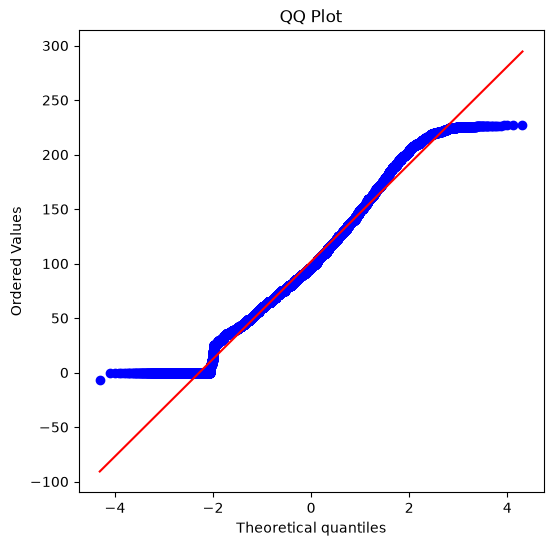

In [5]:
#QQ Plot
plt.figure(figsize=(6,6))

stats.probplot(df["adr"], dist="norm", plot=plt)

plt.title("QQ Plot")

plt.show()

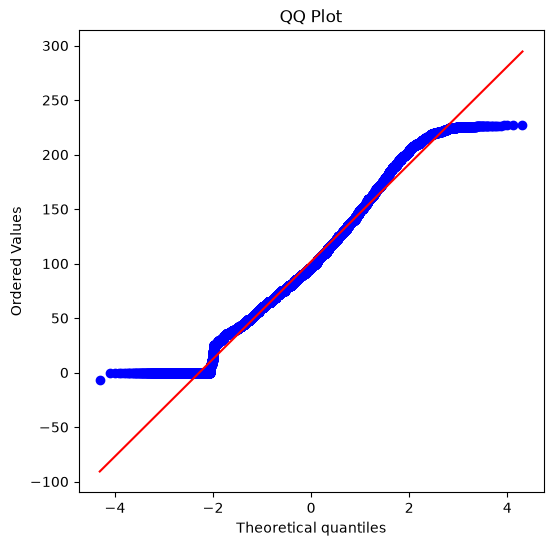

In [6]:
#QQ Plot
plt.figure(figsize=(6,6))

stats.probplot(df["adr"], dist="norm", plot=plt)

plt.title("QQ Plot")

plt.show()

In [7]:
#Homogeneity of Variance

city = df[df["hotel"] == 0]["adr"]

resort = df[df["hotel"] == 1]["adr"]

#Levene Test
stat, p = levene(city, resort)

print("Statistic :", stat)
print("P-value :", p)

if p > 0.05:
    print("Equal Variance Assumed")
else:
    print("Variance is Not Equal")

Statistic : 3111.065877235627
P-value : 0.0
Variance is Not Equal


In [8]:
#Independence Check

print("Checking duplicate observations...")

print("Duplicate Rows :", df.duplicated().sum())

print("Rows :", len(df))

print("Unique Rows :", len(df.drop_duplicates()))

Checking duplicate observations...
Duplicate Rows : 0
Rows : 84718
Unique Rows : 84718


In [9]:
#Correlation Analysis

corr = df.select_dtypes(include=["int64","float64"]).corr()

corr

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,total_stay,total_guests,average_daily_revenue
hotel,1.000000,-0.080800,0.030188,-0.089356,0.002545,0.008982,0.007061,0.158195,0.212062,-0.012189,...,0.371483,-0.034059,-0.038583,-0.202098,0.215660,-0.027006,0.065588,0.216958,-0.001701,0.107208
is_canceled,-0.080800,1.000000,0.184791,0.084643,-0.041498,-0.000185,0.004370,0.057707,0.080909,0.080281,...,0.003839,0.005583,-0.029718,0.133267,-0.180205,-0.115600,-0.886541,0.081785,0.094102,0.132924
lead_time,0.030188,0.184791,1.000000,0.141298,0.013878,0.102799,0.010786,0.234713,0.312889,0.143268,...,0.145201,0.133025,0.055933,0.038425,-0.087909,0.036132,-0.195295,0.320600,0.132423,0.268261
arrival_date_year,-0.089356,0.084643,0.141298,1.000000,-0.233898,-0.524405,-0.011383,0.003030,0.000354,0.031471,...,0.250473,-0.026679,0.061290,0.166288,-0.042357,0.060053,-0.087847,0.001397,0.032270,0.075517
arrival_date_month,0.002545,-0.041498,0.013878,-0.233898,1.000000,0.275887,-0.017525,-0.020673,-0.017069,-0.051944,...,0.007553,0.024967,-0.014659,-0.090519,0.001440,-0.022286,0.040144,-0.020435,-0.079213,-0.087978
arrival_date_week_number,0.008982,-0.000185,0.102799,-0.524405,0.275887,1.000000,0.091932,0.026297,0.026906,0.021773,...,-0.094102,0.013247,-0.057811,0.093189,0.005670,0.044580,-0.008040,0.029857,0.022065,0.071486
arrival_date_day_of_month,0.007061,0.004370,0.010786,-0.011383,-0.017525,0.091932,1.000000,-0.017821,-0.028542,-0.001807,...,0.030182,0.005777,0.016988,0.019485,0.007861,-0.002924,-0.002681,-0.027902,0.006620,-0.013067
stays_in_weekend_nights,0.158195,0.057707,0.234713,0.003030,-0.020673,0.026297,-0.017821,1.000000,0.550538,0.092803,...,0.052456,-0.031849,-0.118597,0.037120,-0.045847,0.032740,-0.049915,0.783790,0.092238,0.614473
stays_in_week_nights,0.212062,0.080909,0.312889,0.000354,-0.017069,0.026906,-0.028542,0.550538,1.000000,0.099496,...,0.156720,0.002452,-0.136134,0.048212,-0.047913,0.037425,-0.073854,0.949945,0.098676,0.744191
adults,-0.012189,0.080281,0.143268,0.031471,-0.051944,0.021773,-0.001807,0.092803,0.099496,1.000000,...,0.222225,-0.014099,-0.099367,0.250310,0.001518,0.113275,-0.091196,0.108747,0.823722,0.192699


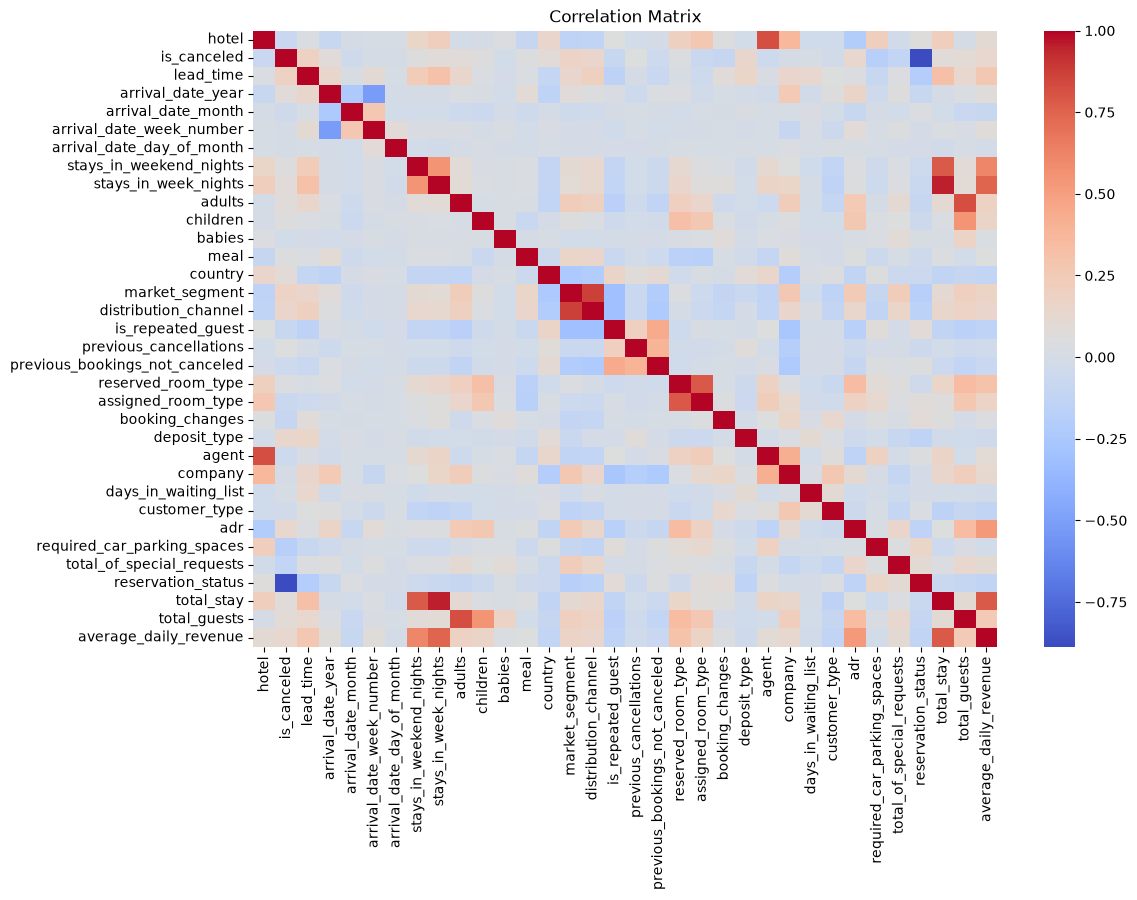

In [10]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

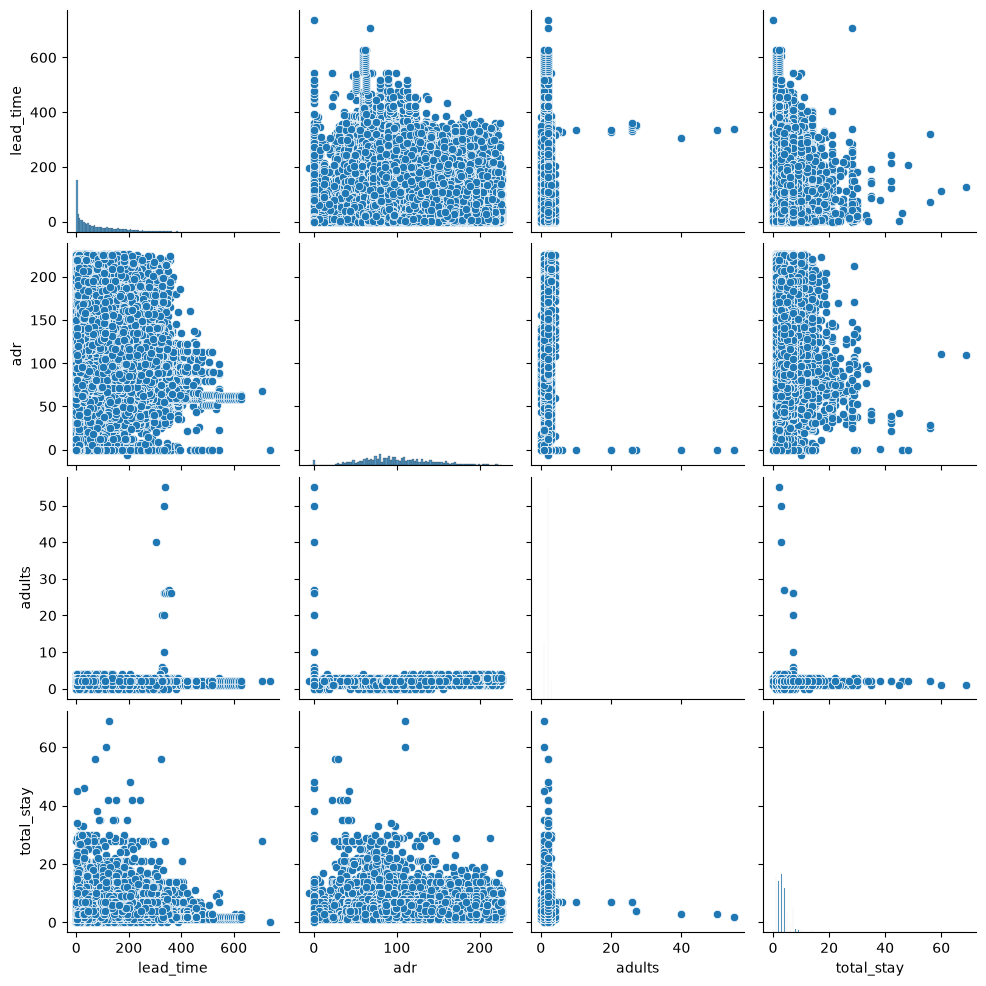

In [11]:
#Pair Plot

pair_columns = [
    "lead_time",
    "adr",
    "adults",
    "total_stay"
]

sns.pairplot(df[pair_columns])

plt.show()

In [12]:
!pip install statsmodels

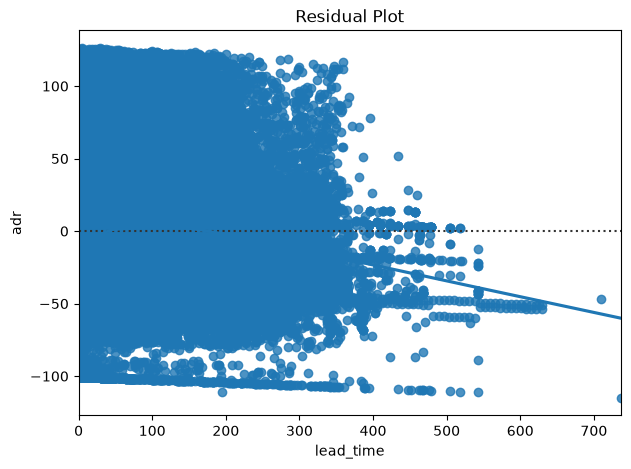

In [13]:
#Residual Plot Acual-predicted

plt.figure(figsize=(7,5))

sns.residplot(
    x=df["lead_time"],
    y=df["adr"],
    lowess=True
)

plt.title("Residual Plot")

plt.show()

In [14]:
#Multicollinearity

features = df[
[
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "total_stay"
]]

#VIF Calculation
vif = pd.DataFrame()

vif["Feature"] = features.columns

vif["VIF"] = [
    variance_inflation_factor(
        features.values,
        i
    )
    for i in range(features.shape[1])
]

vif

,Feature,VIF
0,lead_time,2.095872
1,adr,5.812376
2,adults,6.471115
3,children,1.162747
4,babies,1.009762
5,total_stay,2.895345


In [15]:
#Assumption Summary

summary = pd.DataFrame({

"Assumption":[
"Normality",
"Homogeneity",
"Independence",
"Correlation",
"Multicollinearity"
],

"Method":[
"Shapiro-Wilk",
"Levene Test",
"Duplicate Check",
"Pearson Correlation",
"VIF"
]

})

summary

,Assumption,Method
0,Normality,Shapiro-Wilk
1,Homogeneity,Levene Test
2,Independence,Duplicate Check
3,Correlation,Pearson Correlation
4,Multicollinearity,VIF
